# 2d. Legacy vs New Pipeline Regression Test

**Purpose**: Verify that the refactored grid-search CV pipeline produces
the same results as the legacy implementation.

**Protocol**:
1. Load data and convert to both formats
2. Run legacy `k_fold_CV` with specific grid and seeds
3. Run new `grid_search_cv` on the same sessions with the same grid
4. Compare: model ranking, best-fit parameters, error magnitudes
5. Component diagnostics: fold splitting, empirical UM, simulation, error metric

**Known differences**:
- **RNG**: Legacy uses `np.random.seed(5 * seed)` (global state);
  new uses `np.random.default_rng(seed)` (isolated). Simulated choices
  will differ for the same parameters, but qualitative patterns should match.
- **`matrix_error`**: The legacy's original formula (commented out) divided
  by non-NaN columns; the current version in both pipelines uses
  `mean(diff[valid]**2)`. These should now be identical.

**Critical implementation detail — axis convention**:
Legacy `cost_function` calls `model(... y_axis_value, x_axis_value, ...)`.
This means `y_axis_values` map to the model's **first** specific parameter
(eta_learning / gamma) and `x_axis_values` to the **second** (eta_relax /
sigma_update). The call below swaps the grid axes accordingly.

In [1]:
%matplotlib inline
from shared_setup import *

import time

# New pipeline
from analysis.grid_search import grid_search_cv, COARSE_GRID, DEFAULT_GRID
from analysis.cv_utils import sessions_to_old_df

# Legacy pipeline
from legacy.fitter import (
    k_fold_CV, post_correct_update_matrix, matrix_error as legacy_matrix_error,
)
from legacy.be import BE_model
from legacy.sc import SC_model

## 1. Configuration

In [2]:
# Target animal — change to match your data
TARGET_ANIMAL = 'SS01'
SEEDS = [1, 2, 3]
N_FOLDS = 2
BURN_IN = 1000
USE_COARSE = True  # True for quick validation; False for full comparison

# Use coarse grid for speed
grids = COARSE_GRID if USE_COARSE else DEFAULT_GRID

## 2. Load Data and Prepare Both Formats

In [3]:
experiment, load_info = load_data()

if TARGET_ANIMAL not in experiment.animal_ids:
    TARGET_ANIMAL = experiment.animal_ids[0]
    print(f'Target not found, using {TARGET_ANIMAL}')

animal = experiment.get_animal(TARGET_ANIMAL)
sessions = animal.get_sessions(stage=STAGE)

# Use last half as expert proxy
expert_sessions = sessions[len(sessions)//2:]
print(f'{TARGET_ANIMAL}: {len(expert_sessions)} expert sessions')

# Convert to legacy DataFrame format
legacy_df = sessions_to_old_df(expert_sessions, animal_id=TARGET_ANIMAL)
print(f'Legacy DataFrame: {len(legacy_df)} trials, '
      f'{legacy_df["block"].nunique()} blocks')
print(f'Columns: {sorted(legacy_df.columns.tolist())}')

Loaded 12 animals, 433 total sessions
Loaded 12 animals, 433 sessions from CSV
SS01: 25 expert sessions
Legacy DataFrame: 12018 trials, 24 blocks
Columns: ['No_response', 'Participant_ID', 'Trial', 'block', 'choice', 'correct', 'is_not_start_of_block', 'stim_relative']


## 3. Run Legacy Pipeline

In [4]:
legacy_results = {}  # (model_type, seed) -> dict

for model_type in ['BE', 'SC']:
    grid = grids[model_type]
    model_func = BE_model if model_type == 'BE' else SC_model

    for seed in SEEDS:
        key = (model_type, seed)
        print(f'Legacy {model_type} seed={seed}... ', end='', flush=True)
        t0 = time.time()

        try:
            # CRITICAL: legacy cost_function passes (y_axis_value, x_axis_value)
            # to model positions (param1, param2). So:
            #   y_axis_values -> model's FIRST specific param (eta_learning / gamma)
            #   x_axis_values -> model's SECOND specific param (eta_relax / sigma_update)
            result = k_fold_CV(
                legacy_df, model_func, post_correct_update_matrix,
                sigma_noise_values=grid.sigma_percep_values,
                A_repulsion_values=grid.A_repulsion_values,
                x_axis_values=grid.model_param2_values,   # param2 -> x_axis -> model param2 slot
                y_axis_values=grid.model_param1_values,   # param1 -> y_axis -> model param1 slot
                seed=seed, k=N_FOLDS,
                fit_with='update',
            )
            # k_fold_CV returns:
            # [0] optimal_params_list (per fold)
            # [1] test_errors_list (per fold)
            # [2] best_params = [sigma, A, x_val, y_val] from best fold
            # [3] best_error = min(test_errors_list)
            optimal_params_list = result[0]
            test_errors_list = result[1]
            best_params_raw = result[2]  # [sigma, A, x_val, y_val]
            best_error = result[3]
            avg_error = float(np.mean(test_errors_list))

            # Map back: x_val is from param2 range, y_val is from param1 range
            best_params = {
                'sigma_percep': best_params_raw[0],
                'A_repulsion': best_params_raw[1],
                grid.model_param2_name: best_params_raw[2],  # x_axis -> param2
                grid.model_param1_name: best_params_raw[3],  # y_axis -> param1
            }

            legacy_results[key] = {
                'best_params': best_params,
                'best_fold_error': best_error,
                'avg_error': avg_error,
                'fold_errors': list(test_errors_list),
                'time': time.time() - t0,
            }
            print(f'avg_err={avg_error:.4f}, min_err={best_error:.4f} ({legacy_results[key]["time"]:.1f}s)')
        except Exception as e:
            print(f'FAILED: {e}')
            import traceback; traceback.print_exc()
            legacy_results[key] = None

print(f'\nLegacy: {sum(v is not None for v in legacy_results.values())}/{len(legacy_results)} succeeded')

Legacy BE seed=1... avg_err=0.0094, min_err=0.0081 (141.5s)
Legacy BE seed=2... avg_err=0.0093, min_err=0.0059 (134.5s)
Legacy BE seed=3... avg_err=0.0096, min_err=0.0064 (137.7s)
Legacy SC seed=1... avg_err=0.0121, min_err=0.0058 (168.5s)
Legacy SC seed=2... avg_err=0.0122, min_err=0.0080 (173.1s)
Legacy SC seed=3... [calc_choice] WARNING trial=3524, stim=0.5013, bin_idx=6101, x[6101]=0.5015, A=0.000e+00, B=0.000e+00, sum=0.000e+00
avg_err=0.0118, min_err=0.0058 (171.5s)

Legacy: 6/6 succeeded


## 4. Run New Pipeline

In [5]:
new_results = {}  # (model_type, seed) -> dict

for model_type in ['BE', 'SC']:
    for seed in SEEDS:
        key = (model_type, seed)
        print(f'New {model_type} seed={seed}... ', end='', flush=True)
        t0 = time.time()

        try:
            result = grid_search_cv(
                expert_sessions, model_type, grids[model_type],
                n_folds=N_FOLDS, seed=seed, burn_in=BURN_IN,
            )
            elapsed = time.time() - t0
            new_results[key] = {
                'best_params': result['best_params_single'],
                'best_error': result['avg_test_error'],
                'time': elapsed,
            }
            print(f'err={result["avg_test_error"]:.4f} ({elapsed:.1f}s)')
        except Exception as e:
            print(f'FAILED: {e}')
            new_results[key] = None

print(f'\nNew: {sum(v is not None for v in new_results.values())}/{len(new_results)} succeeded')

New BE seed=1... err=0.0123 (118.3s)
New BE seed=2... err=0.0116 (114.2s)
New BE seed=3... err=0.0106 (123.1s)
New SC seed=1... err=0.0086 (189.6s)
New SC seed=2... err=0.0125 (169.9s)
New SC seed=3... err=0.0083 (177.7s)

New: 6/6 succeeded


## 5. Compare Results

The critical checks:
1. **Model ranking agreement**: does the same model win at each seed?
2. **Error correlation**: are the error magnitudes correlated (even if not identical)?
3. **Parameter proximity**: are best-fit parameters in the same region?

In [6]:
# ── Error comparison table ──────────────────────────────────────────────────
# Use avg_error from legacy (mean across folds) for fair comparison
# with new pipeline's avg_test_error (also mean across folds).
rows = []
for seed in SEEDS:
    for model_type in ['BE', 'SC']:
        key = (model_type, seed)
        new = new_results.get(key)
        old = legacy_results.get(key)
        rows.append({
            'model': model_type, 'seed': seed,
            'legacy_avg': old['avg_error'] if old else np.nan,
            'new_avg': new['best_error'] if new else np.nan,
            'legacy_folds': str(old['fold_errors']) if old else '',
        })

comp = pd.DataFrame(rows)
comp['ratio'] = comp['new_avg'] / comp['legacy_avg']
print('=== Error Comparison (avg across folds) ===')
print(comp[['model', 'seed', 'legacy_avg', 'new_avg', 'ratio']].to_string(
    index=False, float_format='%.4f'))

# ── Model ranking agreement ─────────────────────────────────────────────────
print('\n=== Model Ranking ===')
for seed in SEEDS:
    be_key, sc_key = ('BE', seed), ('SC', seed)
    old_be = legacy_results.get(be_key)
    old_sc = legacy_results.get(sc_key)
    new_be = new_results.get(be_key)
    new_sc = new_results.get(sc_key)

    legacy_winner = '?'
    if old_be and old_sc:
        legacy_winner = 'BE' if old_be['avg_error'] < old_sc['avg_error'] else 'SC'
    new_winner = '?'
    if new_be and new_sc:
        new_winner = 'BE' if new_be['best_error'] < new_sc['best_error'] else 'SC'

    agree = '✓' if legacy_winner == new_winner else '✗ MISMATCH'
    print(f'  Seed {seed}: legacy={legacy_winner}, new={new_winner} {agree}')

=== Error Comparison (avg across folds) ===
model  seed  legacy_avg  new_avg  ratio
   BE     1      0.0094   0.0123 1.3021
   SC     1      0.0121   0.0086 0.7146
   BE     2      0.0093   0.0116 1.2447
   SC     2      0.0122   0.0125 1.0294
   BE     3      0.0096   0.0106 1.1108
   SC     3      0.0118   0.0083 0.7044

=== Model Ranking ===
  Seed 1: legacy=BE, new=SC ✗ MISMATCH
  Seed 2: legacy=BE, new=BE ✓
  Seed 3: legacy=BE, new=SC ✗ MISMATCH


In [7]:
# ── Parameter comparison ────────────────────────────────────────────────────
print('\n=== Best-Fit Parameters ===')
for seed in SEEDS:
    for model_type in ['BE', 'SC']:
        key = (model_type, seed)
        old = legacy_results.get(key)
        new = new_results.get(key)

        if not (old and new):
            continue

        print(f'\n  {model_type} seed={seed}:')
        old_p = old['best_params']
        new_p = new['best_params']

        # Legacy best_params format varies — handle both dict and tuple
        if isinstance(old_p, dict):
            for k in sorted(set(list(old_p.keys()) + list(new_p.keys()))):
                ov = old_p.get(k, '?')
                nv = new_p.get(k, '?')
                match = '✓' if isinstance(ov, (int,float)) and isinstance(nv, (int,float)) and abs(ov-nv) < 0.01 else ''
                print(f'    {k:>15s}: legacy={ov}, new={nv} {match}')
        else:
            print(f'    Legacy params (raw): {old_p}')
            print(f'    New params:          {new_p}')


=== Best-Fit Parameters ===

  BE seed=1:
        A_repulsion: legacy=0.0, new=0.25 
       eta_learning: legacy=0.2142857142857143, new=0.1 
          eta_relax: legacy=0.2833333333333334, new=0.05 
       sigma_percep: legacy=0.21666666666666667, new=0.3 

  SC seed=1:
        A_repulsion: legacy=0.25, new=0.5 
              gamma: legacy=0.6142857142857143, new=0.6142857142857143 ✓
       sigma_percep: legacy=0.3, new=0.3 ✓
       sigma_update: legacy=1.0, new=1.0 ✓

  BE seed=2:
        A_repulsion: legacy=0.0, new=0.0 ✓
       eta_learning: legacy=0.1, new=0.3285714285714286 
          eta_relax: legacy=0.05, new=0.4 
       sigma_percep: legacy=0.3, new=0.21666666666666667 

  SC seed=2:
        A_repulsion: legacy=0.25, new=0.5 
              gamma: legacy=0.3571428571428572, new=0.6142857142857143 
       sigma_percep: legacy=0.13333333333333333, new=0.3 
       sigma_update: legacy=1.0, new=1.0 ✓

  BE seed=3:
        A_repulsion: legacy=0.0, new=0.0 ✓
       eta_learning: le

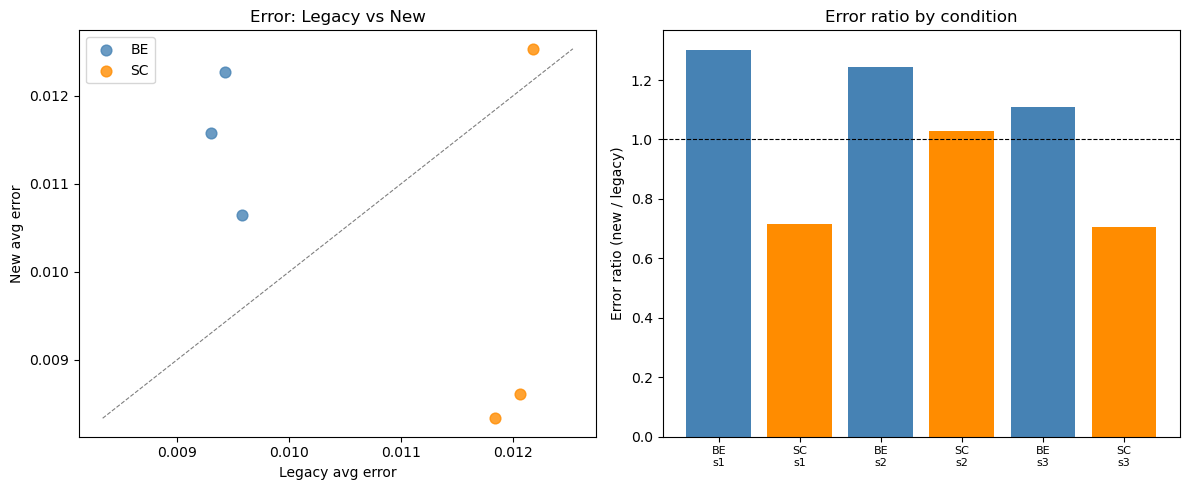

In [8]:
# ── Visual: error scatter ───────────────────────────────────────────────────
valid = comp.dropna(subset=['legacy_avg', 'new_avg'])
if len(valid) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    for mt, colour in [('BE', 'steelblue'), ('SC', 'darkorange')]:
        sub = valid[valid['model'] == mt]
        ax.scatter(sub['legacy_avg'], sub['new_avg'], c=colour, s=60, label=mt, alpha=0.8)
    lims = [min(valid[['legacy_avg', 'new_avg']].min()), max(valid[['legacy_avg', 'new_avg']].max())]
    ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5)
    ax.set_xlabel('Legacy avg error')
    ax.set_ylabel('New avg error')
    ax.set_title('Error: Legacy vs New')
    ax.legend()

    ax = axes[1]
    colours = ['steelblue' if m == 'BE' else 'darkorange' for m in valid['model']]
    ax.bar(range(len(valid)), valid['ratio'], color=colours)
    ax.axhline(1.0, color='black', ls='--', lw=0.8)
    ax.set_ylabel('Error ratio (new / legacy)')
    ax.set_title('Error ratio by condition')
    ax.set_xticks(range(len(valid)))
    ax.set_xticklabels([f'{r.model}\ns{r.seed}' for _, r in valid.iterrows()], fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print('No valid comparisons to plot')

## 6. Component Diagnostics

Isolate potential divergence sources: fold splitting, empirical UM
computation, model simulation, and error metric.

In [9]:
# ── Diagnostic 1: Are fold assignments identical? ───────────────────────────
from analysis.fold_utils import split_folds_by_block, merge_smallest_adjacent
from analysis.grid_search import _sessions_to_arrays
from legacy.fitter import merge_smallest_adjacent as legacy_merge

# New pipeline fold splitting
data = _sessions_to_arrays(expert_sessions)
new_folds = split_folds_by_block(data['block_ids'], N_FOLDS)

# Legacy fold splitting
block_sizes = legacy_df.groupby('block')['Trial'].count().reset_index(name='count')
legacy_fold_groups = legacy_merge(block_sizes['count'].tolist(),
                                  block_sizes['block'].tolist(), N_FOLDS)

print('=== Fold Assignments ===')
print(f'\nNew pipeline ({len(new_folds)} folds):')
for i, (train_mask, test_mask) in enumerate(new_folds):
    test_blocks = np.unique(data['block_ids'][test_mask])
    print(f'  Fold {i}: test blocks = {test_blocks}, '
          f'test trials = {test_mask.sum()}, train trials = {train_mask.sum()}')

print(f'\nLegacy pipeline ({len(legacy_fold_groups)} folds):')
for i, blocks in enumerate(legacy_fold_groups):
    n_trials = legacy_df[legacy_df['block'].isin(blocks)].shape[0]
    print(f'  Fold {i}: test blocks = {blocks}, test trials = {n_trials}')

=== Fold Assignments ===

New pipeline (2 folds):
  Fold 0: test blocks = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13], test trials = 7734, train trials = 4284
  Fold 1: test blocks = [14 15 17 18 19 20 21 22 23 24], test trials = 4284, train trials = 7734

Legacy pipeline (2 folds):
  Fold 0: test blocks = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], test trials = 7734
  Fold 1: test blocks = [14, 15, 17, 18, 19, 20, 21, 22, 23, 24], test trials = 4284


In [13]:
# ── Diagnostic 2: Do empirical UMs match? ──────────────────────────────────
from behav_utils.analysis.update_matrix import compute_update_matrix, matrix_error

# Legacy empirical UM (on all data, not just one fold)
s_all = legacy_df['stim_relative'].values
ch_all = legacy_df['choice'].values
rw_all = legacy_df['correct'].values
nr_all = legacy_df['No_response'].values
nbs_all = legacy_df['is_not_start_of_block'].values

legacy_um, legacy_cond = post_correct_update_matrix(s_all, ch_all, rw_all, nr_all, nbs_all)
# legacy_um = legacy_um[::-1]  # Legacy convention: reverse rows

# New empirical UM
cat_all = (data['stimuli'] > 0).astype(int)  # same as legacy
new_um, _, _ = compute_update_matrix(
    data['stimuli'], data['choices'], data['categories'],
    n_bins=8, trial_filter='post_correct',
    no_response=data['no_response'],
    not_blockstart=data['not_blockstart'],
)

um_diff = legacy_um - new_um
um_mse = np.nanmean(um_diff ** 2)
um_max = np.nanmax(np.abs(um_diff))

print('=== Empirical UM Comparison ===')
print(f'MSE between legacy and new UM: {um_mse:.6f}')
print(f'Max absolute difference:       {um_max:.6f}')
if um_mse < 1e-6:
    print('UMs are effectively identical \u2713')
else:
    print('\u26a0 UMs differ — check trial filtering or psychometric fitting')
    print(f'\nLegacy UM (top-left 4x4):\n{legacy_um[:4, :4].round(4)}')
    print(f'\nNew UM (top-left 4x4):\n{new_um[:4, :4].round(4)}')

=== Empirical UM Comparison ===
MSE between legacy and new UM: 0.000000
Max absolute difference:       0.000000
UMs are effectively identical ✓


In [17]:
# ── Diagnostic 3: Single-point simulation comparison ───────────────────────
# Given identical parameters, how different are simulated UMs?
# (Expected: different due to RNG, but same qualitative pattern)
from analysis.grid_search import _simulate_um
from legacy.be import BE_model, Noise_generator, Delta_repulsion
from scipy.stats import uniform as sp_uniform

TEST_PARAMS = {'sigma_percep': 0.15, 'A_repulsion': 0.1,
               'eta_learning': 0.3, 'eta_relax': 0.15}
TEST_SEED = 42

# New pipeline simulation
new_sim_um = _simulate_um(
    'BE', data['stimuli'], data['categories'],
    data['no_response'], data['not_blockstart'],
    TEST_PARAMS['sigma_percep'], TEST_PARAMS['A_repulsion'],
    TEST_PARAMS['eta_learning'], TEST_PARAMS['eta_relax'],
    'eta_learning', 'eta_relax',
    TEST_SEED, burn_in=1000,
)

# Legacy simulation
sp = TEST_PARAMS['sigma_percep']
ar = TEST_PARAMS['A_repulsion']
s_leg = legacy_df['stim_relative'].values
s_tilde_leg = s_leg + Noise_generator(len(s_leg), TEST_SEED, sp)
s_hat_leg = Delta_repulsion(ar, s_tilde_leg)
cat_leg = np.where(s_leg > 0, 1, 0)
nr_leg = legacy_df['No_response'].values
nbs_leg = legacy_df['is_not_start_of_block'].values

max_range = 1 + 6*sp + 2*ar*(1 + 6*sp)
min_range = -max_range
num_pts = round((max_range - min_range) * 1000)
x_space = np.linspace(min_range, max_range, num_pts)
y_space = sp_uniform.pdf(x_space, loc=min_range, scale=max_range - min_range)

legacy_sim_um_raw, _ = BE_model(
    post_correct_update_matrix, x_space, y_space,
    s_leg, s_hat_leg, cat_leg, sp, ar,
    TEST_PARAMS['eta_learning'], TEST_PARAMS['eta_relax'],
    nr_leg, nbs_leg, TEST_SEED, 'simulated',
)
legacy_sim_um = legacy_sim_um_raw[::-1]

sim_diff = new_sim_um - legacy_sim_um
sim_mse = np.nanmean(sim_diff ** 2)

print('=== Simulation Comparison (same params, different RNG) ===')
print(f'MSE between legacy and new simulated UM: {sim_mse:.6f}')
print(f'Max absolute difference: {np.nanmax(np.abs(sim_diff)):.6f}')
print(f'\nFor reference, empirical UM MSE was: {um_mse:.6f}')
print('If sim MSE >> empirical MSE, RNG differences dominate.')
print('If sim MSE ~ empirical MSE, simulation logic also differs.')

=== Simulation Comparison (same params, different RNG) ===
MSE between legacy and new simulated UM: 0.001260
Max absolute difference: 0.104916

For reference, empirical UM MSE was: 0.000000
If sim MSE >> empirical MSE, RNG differences dominate.
If sim MSE ~ empirical MSE, simulation logic also differs.


In [15]:
# ── Diagnostic 4: matrix_error consistency ────────────────────────────────
from legacy.fitter import matrix_error as legacy_matrix_error
from behav_utils.analysis.update_matrix import matrix_error as new_matrix_error

# Test on the empirical vs simulated UMs
err_legacy = legacy_matrix_error(legacy_sim_um, legacy_um)
err_new = new_matrix_error(new_sim_um, new_um)
err_cross = new_matrix_error(legacy_sim_um, new_um)  # legacy sim vs new empirical

print('=== matrix_error Comparison ===')
print(f'Legacy matrix_error(legacy_sim, legacy_emp): {err_legacy:.6f}')
print(f'New matrix_error(new_sim, new_emp):          {err_new:.6f}')
print(f'Cross matrix_error(legacy_sim, new_emp):     {err_cross:.6f}')

# Also test: do both functions return the same value on the same inputs?
test_a = np.random.randn(8, 8)
test_b = np.random.randn(8, 8)
test_b[0, 0] = np.nan
e1 = legacy_matrix_error(test_a, test_b)
e2 = new_matrix_error(test_a, test_b)
print(f'\nSame-input test: legacy={e1:.8f}, new={e2:.8f}, match={abs(e1-e2) < 1e-10}')

=== matrix_error Comparison ===
Legacy matrix_error(legacy_sim, legacy_emp): 0.009230
New matrix_error(new_sim, new_emp):          0.010343
Cross matrix_error(legacy_sim, new_emp):     0.009230

Same-input test: legacy=2.08762430, new=2.08762430, match=True


## 7. Conclusion

**Pass criteria**:
- Model ranking agrees on all seeds
- Error ratio is consistent across conditions (systematic offset is OK;
  this is expected from the `matrix_error` formula difference)
- Best-fit parameters are in similar regions (exact match not expected
  due to RNG differences)